In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from pandas_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor,     GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [2]:
filePath = '../files/project_files/startup_funding.csv'
data = pd.read_csv(filePath)

In [3]:
data.drop('Sr No', axis=1, inplace=True)
data.drop('Remarks', axis=1, inplace=True)

In [4]:
data

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"
...,...,...,...,...,...,...,...,...
3039,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000"
3040,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000"
3041,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000"
3042,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN


In [5]:
data['Amount in USD'] = data['Amount in USD'].str.replace(',', '')
data['Amount in USD'] = pd.to_numeric(data['Amount in USD'], errors='coerce')

In [6]:
data

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
1,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
2,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
4,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0
...,...,...,...,...,...,...,...,...
3039,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,4500000.0
3040,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,825000.0
3041,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,1500000.0
3042,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN


In [7]:
data['Industry Vertical'].replace('E-Commerce', 'E-commerce')
data['Industry Vertical'].replace('Ecommerce', 'E-commerce')
data['Industry Vertical'].replace('SaaS, Ecommerce', 'E-commerce')
data['Industry Vertical'].replace('eCommece', 'E-commerce')
data['Industry Vertical'].replace('eCommerce', 'E-commerce')
data['Industry Vertical'].replace('SaaS, Ecommerce', 'E-commerce')

0                    E-Tech
1            Transportation
2                E-commerce
3                   FinTech
4       Fashion and Apparel
               ...         
3039                    NaN
3040                    NaN
3041                    NaN
3042                    NaN
3043                    NaN
Name: Industry Vertical, Length: 3044, dtype: object

# Visualising data

Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: Industry Vertical, dtype: int64


/home/dhruv/Environments/ml/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


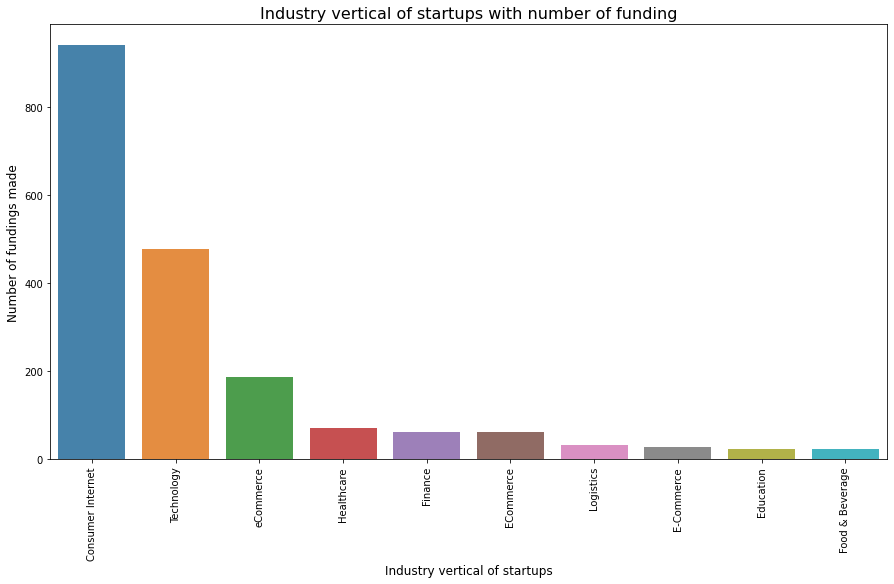

In [8]:
industry = data['Industry Vertical'].value_counts().head(10)
print(industry)
plt.figure(figsize=(15,8))
sns.barplot(industry.index, industry.values, alpha=0.9)
plt.xticks(rotation='vertical')
plt.xlabel('Industry vertical of startups', fontsize=12)
plt.ylabel('Number of fundings made', fontsize=12)
plt.title("Industry vertical of startups with number of funding", fontsize=16)
plt.show()

In [9]:
data['Industry Vertical'].value_counts()[:10]

Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: Industry Vertical, dtype: int64

In [10]:
data['Industry Vertical'].unique()

array(['E-Tech', 'Transportation', 'E-commerce', 'FinTech',
       'Fashion and Apparel', 'Logistics', 'Hospitality', 'Technology',
       'E-Commerce', 'Aerospace', 'B2B-focused foodtech startup',
       'Finance', 'Video', 'Gaming', 'Software', 'Health and wellness',
       'Education', 'Food and Beverage', 'Health and Wellness',
       'B2B Marketing', 'Video Games', 'SaaS', 'Last Mile Transportation',
       'Healthcare', 'Customer Service', 'B2B', 'Consumer Goods',
       'Advertising, Marketing', 'IoT', 'Information Technology',
       'Consumer Technology', 'Accounting', 'Retail',
       'Customer Service Platform', 'Automotive', 'EdTech', 'Services',
       'Compliance', 'Transport', 'Artificial Intelligence', 'Tech',
       'Health Care', 'Luxury Label', 'Waste Management Service',
       'Deep-Tech', 'Agriculture', 'Energy', 'Digital Media', 'Saas',
       'Automobile', 'Agtech', 'Social Media', 'Fintech', 'Edtech', 'AI',
       'Ecommerce', 'Nanotechnology', 'Services Platfo

In [11]:
data['Industry Vertical'].replace('Agtech', 'Agriculture')
data['Industry Vertical'].replace('Mobile Commerce for Farmers', 'Agriculture')

0                    E-Tech
1            Transportation
2                E-commerce
3                   FinTech
4       Fashion and Apparel
               ...         
3039                    NaN
3040                    NaN
3041                    NaN
3042                    NaN
3043                    NaN
Name: Industry Vertical, Length: 3044, dtype: object

In [12]:
data[data['Industry Vertical'] == 'Agriculture'].head(20)

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
81,06/06/2019,Sistema.bio,Agriculture,Hybrid Reactor Biodigestor,Nairobi,"Shell Foundation, DILA CAPITAL, Engie RDE Fund...",NaN,2739034.68
379,20/02/2018,Agricxlab,Agriculture,Agri-tech,Mumbai,Ankur Capital,Seed / Angel Funding,500000.00


In [16]:
data[data['Industry Vertical'] == 'Consumer Internet'].to_string()


'     Date dd/mm/yyyy                  Startup Name  Industry Vertical                                                                                            SubVertical       City  Location                                                                                                                                                            Investors Name       InvestmentnType  Amount in USD\n151       01/09/2018                       Netmeds  Consumer Internet                                                                                  Online Pharmacy Chain              Chennai                                                                                                                    Sistema Asia Fund, Sistema JSFC and Tanncam Investment        Private Equity     35000000.0\n153       03/09/2018                    Daily hunt  Consumer Internet                                                                   News and ebooks Mobile App\\\\xc2\\\\xa0            Bengalu

In [17]:
filepath = "C:\\Users\\Dhruv\\Machine-Learning\\code\\files\\exported_files\\"
data.to_excel(filepath + 'funding_data.xlsx', index=False)

ModuleNotFoundError: No module named 'openpyxl'